# VEST neutral-beam analysis with NUBEAM

What does a 200 kW hydrogen beam actually do to a VEST plasma -- where is it
absorbed, what fraction reaches the plasma at all, and where does the rest go?

This notebook answers that by running NUBEAM, from inputs stored in the
repository, and reading its output. It keeps three kinds of number strictly
apart, because conflating them is the easiest way to overstate what a
simulation establishes:

| | |
| --- | --- |
| **Machine description** | VEST geometry and beamline hardware, from `mdescr` |
| **Modelling input** | beam energy and power, background profiles -- chosen for this run |
| **NUBEAM output** | heating, current drive, deposition, losses -- what the code computed |

Nothing here is measured beam data. The beam configuration is what this NUBEAM
case assumes, and it is labelled that way throughout.

Reading order is top to bottom: the run, its inputs, then geometry, profiles,
the power budget, and finally what the run does and does not establish.


## 0. Setup

NUBEAM is an external Fortran executable. VAFT resolves
`$NUBEAMHOME/bin/nubeam_comp_exec`, the same `$XHOME` convention CHEASE, EFIT,
GPEC and TES follow. Without it the notebook explains what each section would
show and stops.

The case is in the repository: `vaft/data/nubeam/vest_case`, about 120 kB of
namelists, profiles, machine description and one G-EQDSK. **Inputs are stored,
outputs are not.** Running them regenerates roughly 260 MB of Plasma State,
marker and log files, which is what makes this analysis reproducible without
carrying a quarter of a gigabyte in Git -- and means the numbers below are
recomputed rather than recited.

The run goes into a temporary directory created by
`vaft.compat.short_temporary_directory` rather than `tempfile.mkdtemp`. NUBEAM
composes every output filename in a `character*140` buffer and truncates past
it with no diagnostic, so the path length is a correctness constraint, not a
tidiness one; on macOS the default `$TMPDIR` alone is 48 characters. Section 9
removes the directory.

In [1]:
import contextlib
import os
import time
from pathlib import Path

# Resolve against the repository root, not the kernel's cwd: Jupyter starts
# in notebooks/, which would otherwise create a nested notebooks/notebooks/.
_repo_root = Path.cwd()
if _repo_root.name == "notebooks":
    _repo_root = _repo_root.parent
OUTPUT_DIR = Path(os.environ.get(
    "VAFT_DOCS_OUTPUT_DIR", _repo_root / "notebooks" / "outputs" / "docs"
))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    _ipython = get_ipython()
except NameError:
    _ipython = None
if _ipython is None:
    os.environ.setdefault("MPLBACKEND", "Agg")
elif "IPKernelApp" in _ipython.config:
    _ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np

from vaft.code import nubeam
from vaft.compat import short_temporary_directory
from vaft.plot import nubeam as nbplot

plt.rcParams["figure.dpi"] = 110

CASE = nubeam.packaged_vest_case()

# NUBEAM derives every output filename from the run id in `inputf`, so the id
# is read from the case rather than chosen here -- the path budget in section 1
# depends on it, and the two must not be able to drift apart.
RUNID = nubeam.inputf_runid((CASE.input_dir / "inputf").read_text(encoding="utf-8"))
# Run size. `RUN_SIZE = "reference"` is the default and is the configuration
# the case ships and `external/nubeam/VALIDATION.md` validated. The NTCC
# distribution builds no MPI executable here, so it is serial.
#
# The two axes were measured on this case rather than guessed, and they behave
# very differently:
#
#   particles (1 step)          steps (2000 particles)
#     2000  ->  136 s             1 step   ->  136 s
#    10000  ->  690 s             5 steps  ->  952 s
#
#   ... and the effect on the answer:
#
#                        electron heating   driven current
#     2000 x 1 step            118 kW            194 A
#    10000 x 1 step            120 kW            194 A
#     2000 x 5 steps           131 kW            220 A
#
# Five times the particles costs five times the runtime and moves the totals by
# about one percent. Five times the steps costs seven times the runtime and
# moves them by 11-41%. The step count is what carries the physics here -- the
# fast-ion population is still building through the first millisecond -- and
# the particle count mostly buys smoothness.
#
# So "reduced" keeps all five steps and cuts only the particles: about sixteen
# minutes for totals within a few percent of the reference. "quick" cuts both
# and finishes in two minutes, enough to exercise the workflow and every
# consistency check below, but its absolute numbers are not a VEST result.
#
# The committed default is "reduced": it keeps every step, which is the axis
# that carries the physics, and cuts only the particle count. Sixteen minutes
# against roughly six hours for "reference", for totals within a few percent.
# The figures and summary committed with this page came from it, and the
# summary records which size produced them.
RUN_SIZE = "reduced"

_SIZES = {
    "reference": ("5x0.001", None),
    "reduced": ("5x0.001", 2000),
    "quick": ("1x0.001", 2000),
}
if RUN_SIZE not in _SIZES:
    raise ValueError(f"RUN_SIZE must be one of {sorted(_SIZES)}, got {RUN_SIZE!r}")
_repeat, _nptcls = _SIZES[RUN_SIZE]

CONFIG = nubeam.NUBEAMConfig(runid=RUNID, repeat_count=_repeat, nptcls=_nptcls)

EXECUTABLE = nubeam.find_nubeam_executable(CONFIG)
HAVE_NUBEAM = EXECUTABLE is not None

print(f"run size    {RUN_SIZE}  ({_repeat},"
      f" {_nptcls if _nptcls is not None else 'namelist default'} particles)")
print(f"case        {CASE.input_dir}")
print(f"equilibrium {CASE.gfile.name}")
print(f"run id      {RUNID}")
print(f"executable  {EXECUTABLE}")
if not HAVE_NUBEAM:
    print(
        "\nNUBEAM was not found. Set $NUBEAMHOME to an installation root -- "
        "external/nubeam/README.md\nbuilds one -- and re-run. "
        "Every section below reports what it would show and skips."
    )

run size    reduced  (5x0.001, 2000 particles)
case        /Users/yun/git/vaft/.claude/worktrees/nubeam-macos-build-fixes-1a96b9/vaft/data/nubeam/vest_case
equilibrium g020000.015100
run id      FUSMA_NUBEAM
executable  /Users/yun/git/nubeam/local/bin/nubeam_comp_exec


## 1. Run the case

`run_nubeam_case` does the three steps NUBEAM needs in order: stage the inputs
into the work directory, build a Plasma State from the equilibrium and
profiles, then run NUBEAM's init and step phases over it.

Staging is not a plain copy. The equilibrium is placed under a fixed name and
line 2 of `inputf` is rewritten to point at it, so the case does not depend on
what the G-EQDSK happened to be called upstream -- which is why the shipped
`inputf` still names the original author's file and nothing reads that name.

In [2]:
_cleanup = contextlib.ExitStack()
RUN_DIR = None
result = None

if HAVE_NUBEAM:
    RUN_DIR = _cleanup.enter_context(
        short_temporary_directory(
            max_length=CONFIG.workdir_budget, prefix="vaft-nubeam-"
        )
    )
    print(f"work directory  {RUN_DIR}")
    print(f"path budget     {len(str(RUN_DIR))}/{CONFIG.workdir_budget} characters")

    _started = time.monotonic()
    result = nubeam.run_nubeam_case(
        CASE.input_dir, gfile=CASE.gfile, workdir=RUN_DIR, config=CONFIG
    )
    print(f"elapsed         {time.monotonic() - _started:.0f} s")
    if not result.ok:
        print(f"\nNUBEAM did not produce a usable result (rc={result.returncode}).")
        if result.stderr.strip():
            print(result.stderr.strip()[-1500:])

HAVE_RUN = result is not None and result.ok
native = result.outputs_native if result is not None else None

if native is not None:
    print()
    print(f"radial profiles        {len(native.profiles)}")
    print(f"scalar diagnostics     {len(native.scalars)}")
    print(f"deposition markers     {native.birth.count if native.birth else 'not written'}")
    print(f"lost fast ions         {native.lost.count if native.lost else 'not collected'}")
    print(f"power balance blocks   {len(native.power_balance)}")
    print(f"interpolation warnings {native.interpolation_warnings}")
elif HAVE_NUBEAM:
    print("\nNo outputs to read.")
else:
    print(
        "Would stage the case, build its Plasma State, run NUBEAM, and report\n"
        "which products the run produced."
    )

work directory  /tmp/vaft-nubeam-h97_96fr
path budget     25/95 characters


elapsed         1791 s

radial profiles        39
scalar diagnostics     134
deposition markers     2000
lost fast ions         208
power balance blocks   1
interpolation warnings 5748


## 2. Inputs, by provenance

The beam configuration below is a **modelling input**, not a measurement. Beam
power and energy enter through the `profiles` file that `makeprofile` writes,
and the Plasma State records what NUBEAM actually used -- which is the value to
trust, since `mdescr` separately tabulates energy-fraction data at a different
energy that is easy to misread as the injection energy.


In [3]:
import warnings

beam = {}
if HAVE_RUN:
    state = RUN_DIR / f"{native.runid}.cdf"
    if state.is_file():
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            import xarray as xr

            with xr.open_dataset(state, decode_times=False) as ds:
                for key in ("kvolt_nbi", "power_nbi"):
                    if key in ds.variables:
                        beam[key] = (
                            float(np.asarray(ds[key].values).ravel()[0]),
                            ds[key].attrs.get("units", ""),
                        )

if beam:
    print("NUBEAM modelling input (from the profiles file, via the Plasma State)")
    for key, (value, unit) in beam.items():
        print(f"   {key:<12s} {value:>10.4g} {unit}")
    print("\nThese are assumptions of this case, not measured beam parameters.")
else:
    print("Would report beam energy and power, labelled as modelling inputs.")


NUBEAM modelling input (from the profiles file, via the Plasma State)
   kvolt_nbi            10 keV
   power_nbi         2e+05 W

These are assumptions of this case, not measured beam parameters.


The beamline geometry is a **machine description**. It is still NUBEAM-derived
rather than as-built: reconciling it against the real hardware is issue #265.

One value deserves care. `srtcen` is a *signed* tangency radius -- the sign
carries the injection direction -- so it is reported as written rather than as
a magnitude.


In [4]:
geometry = {}
if HAVE_RUN:
    import f90nml

    for descriptor in sorted(RUN_DIR.glob("mdescr_*.dat")):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            parsed = f90nml.read(descriptor)
        for body in parsed.values():
            geometry.update(body)

interesting = (
    ("nbi_src_name", "beam source"),
    ("srtcen", "tangency radius [m], signed"),
    ("zbsc", "source elevation [m]"),
    ("nbshape", "source grid shape"),
    ("b_halfwidth", "source half-width [m]"),
    ("b_halfheight", "source half-height [m]"),
    ("b_hdivergence", "horizontal divergence [deg]"),
    ("b_vdivergence", "vertical divergence [deg]"),
)
if geometry:
    for key, description in interesting:
        if key in geometry:
            value = geometry[key]
            value = value[0] if isinstance(value, list) else value
            print(f"   {description:<30s} {value}")
else:
    print("Would report the beamline geometry from mdescr.")


   beam source                    B_001
   tangency radius [m], signed    -0.22129
   source elevation [m]           0
   source grid shape              Rectangle
   source half-width [m]          0.06
   source half-height [m]         0.21
   horizontal divergence [deg]    1.0
   vertical divergence [deg]      1.0


## 3. Where the beam deposits

NUBEAM writes one marker per deposition track. The top view is the natural one
for a tangential beam -- it shows the chord through the plasma, which a
poloidal projection collapses -- so both are shown.

The birth file stores centimetres and degrees, and says so nowhere; the
plotting layer converts and the axes are metres.


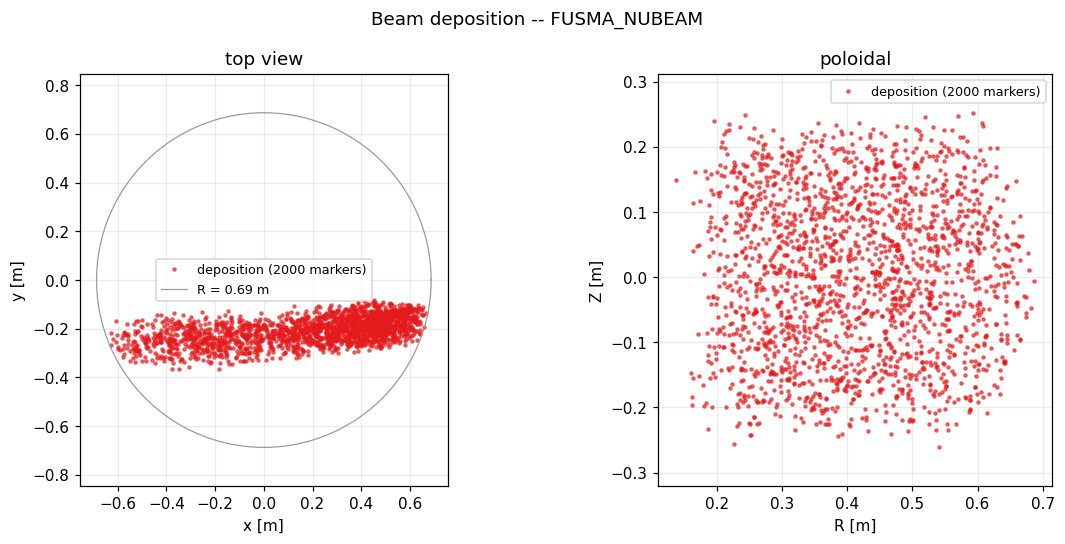

In [5]:
if HAVE_RUN and native.birth is not None:
    figure, axes = plt.subplots(1, 2, figsize=(11, 5))
    nbplot.nubeam_deposition_topview(result, title="top view", ax=axes[0])
    nbplot.nubeam_deposition_poloidal(result, title="poloidal", ax=axes[1])
    figure.suptitle(f"Beam deposition -- {native.runid}")
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / "nbi-deposition.png", dpi=180, bbox_inches="tight")
else:
    print("Would show beam deposition from above and in the poloidal plane.")

## 4. Radial profiles

NUBEAM writes these as **per-zone integrals**, not densities: `pbe` is the
watts deposited in a zone. They are plotted in those units rather than divided
by a zone volume, which would make them derived quantities.

The abscissa is NUBEAM's own `rho`, which is toroidal-flux based.


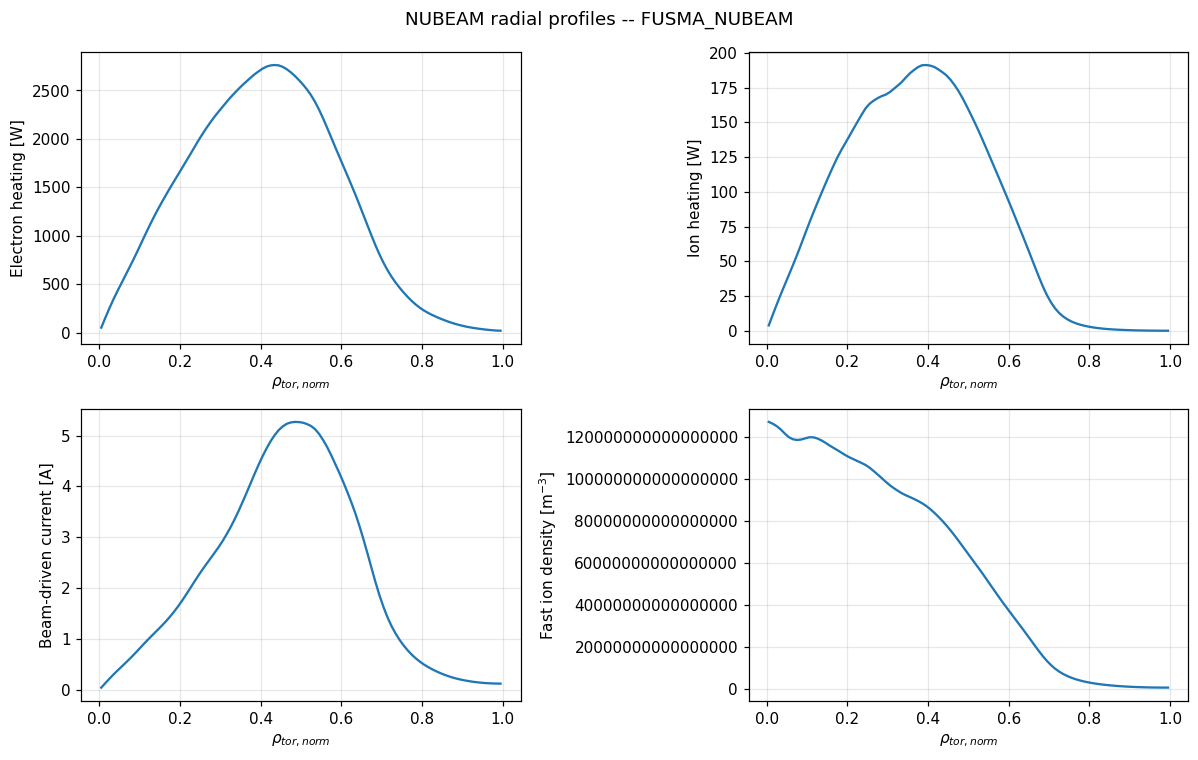

In [6]:
rho = None
if HAVE_RUN:
    state = RUN_DIR / f"{native.runid}.cdf"
    if state.is_file():
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with xr.open_dataset(state, decode_times=False) as ds:
                if "rho_nbi" in ds.variables:
                    rho = np.asarray(ds["rho_nbi"].values)

wanted = ["pbe", "pbi", "curbeam", "nbeami"]
available = [q for q in wanted if HAVE_RUN and q in native.profiles]
missing = [q for q in wanted if q not in available]

if available:
    figure, axes = plt.subplots(2, 2, figsize=(11, 7))
    for panel, quantity in zip(axes.ravel(), available):
        # The y-labels name the quantities, so the per-panel titles would
        # only repeat them eight times over.
        nbplot.nubeam_profile(result, quantity, rho=rho, title="", ax=panel)
    for panel in axes.ravel()[len(available):]:
        panel.set_visible(False)
    figure.suptitle(f"NUBEAM radial profiles -- {native.runid}")
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / "nbi-profiles.png", dpi=180, bbox_inches="tight")
if missing:
    print(f"absent from this run: {', '.join(missing)}")
if not available:
    print("Would show beam heating, driven current and fast ion density.")

### The driven current is toroidal, and that matters

`curbeam` above is a **per-zone toroidal driven current** in amps. It is not a
parallel current density, and the distinction is not bookkeeping. NUBEAM's own
naming settles it: the Plasma State calls the family `curt`, *"total enclosed
toroidal current"*, and `curbeam` sits beside it.

IMAS asks for something else. `j_parallel` is defined as

$$j_\parallel = \frac{\langle \mathbf{J}\cdot\mathbf{B}\rangle}{B_0}$$

and `current_parallel_inside` is its cumulative surface integral.

#### What this notebook used to do, and why it was wrong

An earlier version of the mapping wrote $\Delta I/\Delta A$ into `j_parallel`
and a running sum of `curbeam` into `current_parallel_inside`, describing the
latter as exact. Both were wrong.

$\Delta I/\Delta A$ is the **large-aspect-ratio limit** of the correct
expression — what you get as $F \to R_0B_0$, $\langle B^2\rangle \to B_0^2$ and
$\langle R^{-2}\rangle \to R_0^{-2}$. VEST is about the worst place to invoke
it. It is a spherical tokamak, so the poloidal field is a large fraction of the
total and $\langle B^2\rangle$ greatly exceeds $B_0^2$; and the plasma is
strongly paramagnetic, with $F(\psi) = RB_\phi$ running from 0.0964 T·m on axis
to its 0.0600 T·m vacuum value at the edge — a 61 % variation, so $F$ cannot be
treated as a constant either.

#### What it does now

Assuming the driven current is **field-aligned** on each flux surface,
$\mathbf{J} = \lambda(\psi)\mathbf{B}$, and writing the poloidal area element as
$dA = dV/2\pi R$:

$$\int_{\rm shell} B_\phi\,dA = \frac{F\,\langle R^{-2}\rangle\,\Delta V}{2\pi}
\qquad
\lambda = \frac{2\pi\,\Delta I_\phi}{F\,\langle R^{-2}\rangle\,\Delta V}
\qquad
j_\parallel = \lambda\,\frac{\langle B^2\rangle}{B_0}$$

So the conversion needs real equilibrium geometry: $F(\psi)$,
$\langle B^2\rangle$, $\langle R^{-2}\rangle$ and $B_0$. That is why it lives in
`vaft.process.equilibrium.parallel_current_from_toroidal`, generic enough for
any current-drive source, rather than inside the NUBEAM mapping.

**$\Delta I/\Delta A$ is kept only as a limiting check** — the implementation
must reproduce it as the aspect ratio grows — never as the production path.

#### Why there is no shortcut

The Plasma State *does* contain `jdotb` = $\langle J\cdot B\rangle$, and it is
tempting to read it straight across. It cannot be: it is the **total** plasma
quantity and an *input*. `state_changes.cdf` never updates it, so no
beam-driven $\langle J\cdot B\rangle$ exists in the output at all. The
equilibrium-dependent derivation is a necessity, not a convenience.

But `jdotb` is the best validation available, and the cell below uses it.

#### Provenance

The native toroidal current is **preserved unchanged** in the NUBEAM result
container and is never reinterpreted as an IMAS parallel quantity — IMAS
`core_sources.profiles_1d` has no toroidal-current field to hold it. If the
equilibrium geometry or $B_0$ is unavailable, the derived fields are simply
**left unset**; there is no fallback to the old proxy, because a value shaped
like an IMAS quantity but computed the wrong way is worse than a missing one.


In [7]:
# The size of the correction, and the two checks that justify it.
if HAVE_RUN and native.grid is not None and native.flux_surface is not None:
    from vaft.process.equilibrium import parallel_current_from_toroidal

    B0 = 0.15  # vacuum_toroidal_field.b0 for this equilibrium
    centres = lambda a: 0.5 * (np.asarray(a)[:-1] + np.asarray(a)[1:])
    f_c, gm1_c, gm5_c = native.flux_surface.at_zone_centres()
    driven = np.asarray(native.profiles['curbeam']).ravel()

    derived = parallel_current_from_toroidal(
        driven, f=f_c, gm1=gm1_c, gm5=gm5_c,
        shell_volume=native.grid.zone_volume, b0=B0,
        shell_area=native.grid.zone_area,
    )
    proxy = driven / native.grid.zone_area          # the old large-aspect form
    ratio = derived.j_parallel / proxy

    print('j_parallel, corrected / previous DeltaI-DeltaA:')
    print(f'    min {ratio.min():.3f}   median {np.median(ratio):.3f}   max {ratio.max():.3f}')
    print()
    print('current_parallel_inside:')
    print(f'    native enclosed TOROIDAL current  {driven.sum():8.1f} A')
    print(f'    derived PARALLEL current          {derived.current_parallel_inside[-1]:8.1f} A')
    print()
    print(f'F(psi) varies {f_c[0]:.4f} -> {f_c[-1]:.4f} T.m '
          f'({100 * (f_c[0] / f_c[-1] - 1):.0f}% paramagnetic)')
else:
    print('Would quantify the correction against the previous DeltaI/DeltaA mapping.')


j_parallel, corrected / previous DeltaI-DeltaA:
    min 1.477   median 1.541   max 1.586

current_parallel_inside:
    native enclosed TOROIDAL current     219.9 A
    derived PARALLEL current             337.8 A

F(psi) varies 0.0964 -> 0.0600 T.m (61% paramagnetic)


In [8]:
# Validation 1: the same transformation applied to the TOTAL enclosed toroidal
# current must reproduce xplasma's own <J.B>, computed independently.
# The total current is not purely field-aligned -- it carries a diamagnetic
# part -- so this bounds the assumption rather than proving it.
if HAVE_RUN and native.flux_surface is not None:
    state_file = RUN_DIR / f'{native.runid}.cdf'
    if state_file.is_file():
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            with xr.open_dataset(state_file, decode_times=False) as ds:
                curt = np.asarray(ds['curt'].values)
                jdotb = np.asarray(ds['jdotb'].values)

        total = parallel_current_from_toroidal(
            np.diff(curt), f=f_c, gm1=gm1_c, gm5=gm5_c,
            shell_volume=native.grid.zone_volume, b0=B0,
        )
        agreement = total.j_parallel / (centres(jdotb) / B0)
        print('transformation applied to the total current, against xplasma <J.B>/B0:')
        print(f'    on axis {agreement[0]:.4f}   median {np.median(agreement[:-1]):.4f}')
        print('    (residual grows outward: the omitted diamagnetic term)')
else:
    print('Would cross-check the transformation against the total <J.B>.')


transformation applied to the total current, against xplasma <J.B>/B0:
    on axis 1.0000   median 1.0130
    (residual grows outward: the omitted diamagnetic term)


A hydrogen plasma makes no fusion products, so `pfuse`, `pfusi` and `curfusn`
are legitimately absent rather than zero. NUBEAM says so itself in the step
log. Asking for one reports that rather than drawing a flat line at zero.


In [9]:
if HAVE_RUN:
    try:
        nbplot.build_nubeam_profile(result, "pfuse")
    except nbplot.NUBEAMPlotError as error:
        print(error)
else:
    print("Would demonstrate that an absent quantity is reported, not zero-filled.")


'pfuse' is not in this NUBEAM result. A hydrogen run has no fusion products, so pfuse/pfusi/curfusn are legitimately absent. Available: T0_halo, T0_reco, T0cx, T0sc0, curbeam, eperp_beami, epll_beami, n0_halo, n0_reco, n0norm, nbeami, p0_reco, pb0_halo, pbe, pbi, pbth, pcx_halo, pcx_reco, psc_halo, psc_reco, qbeami, qioniz, qqcx, s0reco, s0reco_e, s0reco_recap, sb0halo, sb0halo_recap, sbedep, sbehalo, sbsce, sbtherm, sprof0, sprof0e, tqbe, tqbi, tqbjxb, tqbth, tqqcx


## 5. The power budget

NUBEAM closes its own energy accounting at the end of each step, including the
residual. This is read from the step log rather than reconstructed from the
profiles -- a reconstruction would be a different number carrying different
assumptions.

This is the single most informative output for a small tokamak, because it
says directly what fraction of the injected power the plasma actually absorbs.


coupled to the plasma as heating: 70.0%
lost to shine-through           19.1%
lost to bad orbit loss          10.5%


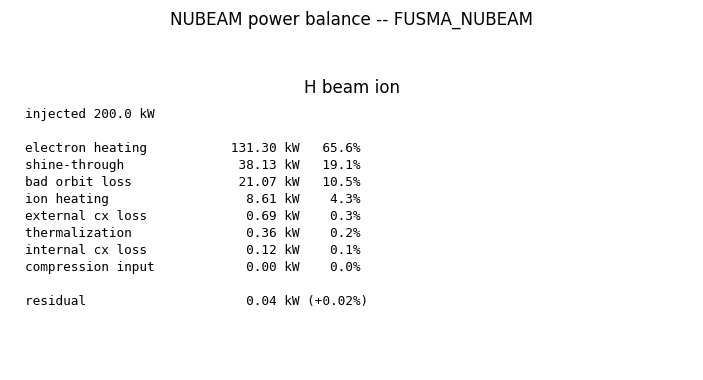

In [10]:
if HAVE_RUN and native.power_balance:
    figure, _ = nbplot.nubeam_power_accounting(result)
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / "nbi-power-balance.png", dpi=180, bbox_inches="tight")

    balance = native.power_balance[0]
    fractions = balance.fractions()
    heating = sum(v for k, v in fractions.items() if "heating" in k)
    print(f"coupled to the plasma as heating: {100 * heating:.1f}%")
    for channel in ("shine-through", "bad orbit loss"):
        if channel in fractions:
            print(f"lost to {channel:<18s}      {100 * fractions[channel]:.1f}%")
else:
    print("Would show NUBEAM's power balance and the absorbed fraction.")

## 6. Lost fast ions

Where NUBEAM stopped following markers. `lstype` separates prompt loss -- ions
lost before completing an orbit -- from orbit loss, and the split matters:
NUBEAM's log labels the whole channel "bad orbit loss" regardless.

These coordinates are already metres, unlike the deposition markers.


channels: {'prompt': 206, 'orbit': 2}


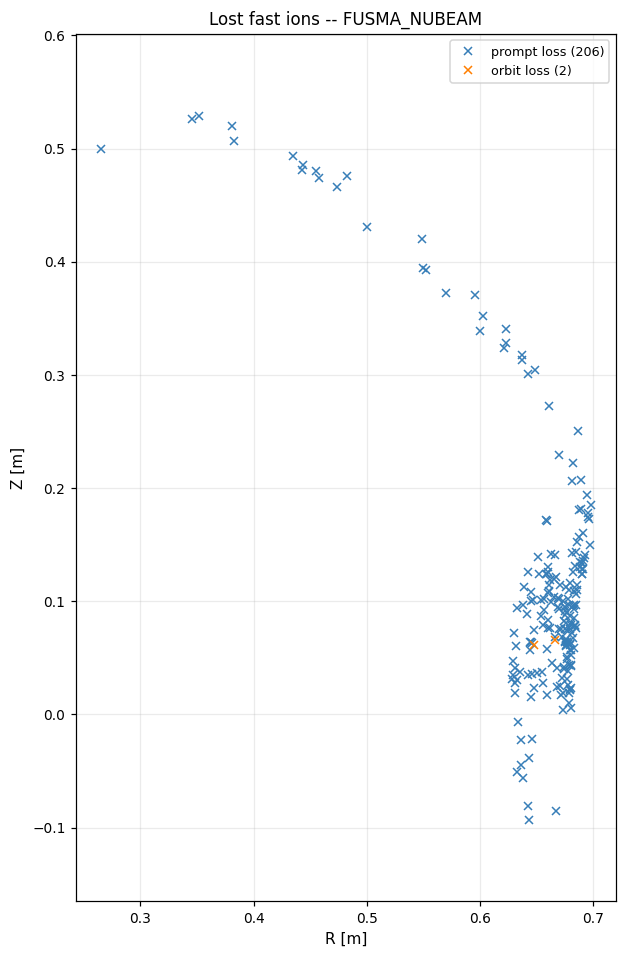

In [11]:
if HAVE_RUN and native.lost is not None and native.lost.count:
    print(f"channels: {native.lost.channel_counts()}")
    figure, _ = nbplot.nubeam_lost_fast_ions(result)
    figure.tight_layout()
elif HAVE_RUN:
    print("This run collected no lost-particle record.")
else:
    print("Would show where fast ions were lost, split by loss channel.")


## 7. Into IMAS

Everything above reads the run directory. Mapping the result into an ODS makes
it outlive that directory, and makes it readable by anything that speaks IMAS.

Two mappings, kept apart on purpose. `nbi` is the beam hardware, from the
NUBEAM machine description -- provenance, not measurement, so the registry
marks it `partial` until the as-built data are reconciled (issue #265).
`core_sources` is what the beam *did* to the plasma.

The cumulative fields are worth a look: NUBEAM writes per-zone integrals, so
`electrons.power_inside` is a running sum with nothing derived, and its last
value should equal the electron heating the power balance reported above.

`j_parallel` and `current_parallel_inside` are the exception to "nothing is
derived": they are computed from the equilibrium geometry, not copied, for
the reasons set out under section 4. A second cross-check on that conversion
is that NUBEAM's own flux-surface averages and the ones VAFT reconstructs
independently from the same g-file agree to about half a percent, and the two
give parallel currents within 0.1 % of each other.


In [12]:
from omas import ODS

import vaft.omas as vomas
from vaft.machine_mapping.core_sources import core_sources_from_nubeam
from vaft.machine_mapping.nbi import nbi as map_nbi, nbi_run_conditions

if HAVE_RUN:
    mapped = ODS()
    map_nbi(mapped)
    nbi_run_conditions(mapped, result)
    # b0 is required for the parallel-current derivation. Without it the
    # mapping leaves j_parallel and current_parallel_inside unset rather
    # than falling back to the old proxy -- try removing it and watch the
    # current-drive plot below stop being offered.
    report = core_sources_from_nubeam(mapped, result, time=0.0, b0=B0)

    print(f"wrote {len(report['written'])} channels; skipped {report['skipped'] or 'nothing'}")
    print()
    balance = native.power_balance[0] if native.power_balance else None
    base = f"core_sources.source.{report['source']}.profiles_1d.0"
    inside = mapped[f"{base}.electrons.power_inside"][-1]
    print(f"electrons.power_inside, last value : {inside / 1e3:8.2f} kW")
    if balance is not None:
        stated = balance.sinks().get('electron heating')
        print(f"NUBEAM's own electron heating      : {stated / 1e3:8.2f} kW")
        print(f"ratio                              : {inside / stated:8.4f}")
else:
    print("Would map the result into nbi and core_sources, and check the")
    print("cumulative fields against NUBEAM's own totals.")


wrote 10 channels; skipped nothing

electrons.power_inside, last value :   131.31 kW
NUBEAM's own electron heating      :   131.30 kW
ratio                              :   1.0001


Mapped, the profiles are discoverable through the plot catalog and read from
the ODS rather than the run. Note the units change: `core_sources` is a
density, so these are W/m^3 where section 4 plotted NUBEAM's per-zone watts.


offered for this ODS: ['nbi_profile_current_drive', 'nbi_profile_electron_heating', 'nbi_profile_ion_heating']


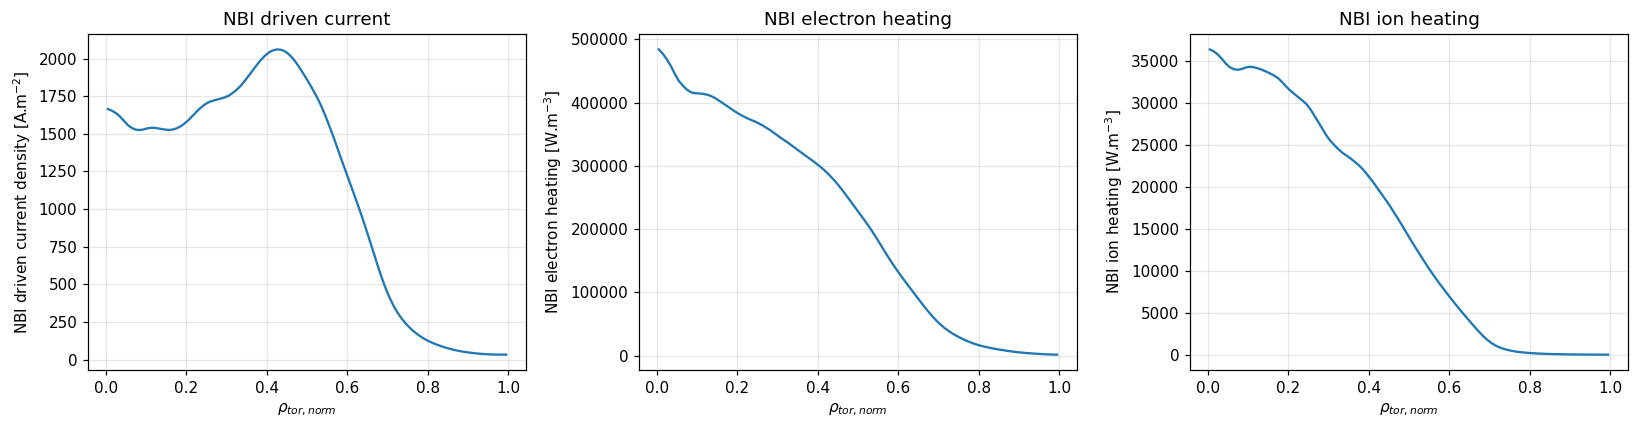

In [13]:
if HAVE_RUN:
    offered = {row['name'] for row in vomas.available_plots(mapped)}
    names = sorted(n for n in offered if n.startswith('nbi_'))
    print('offered for this ODS:', names)

    figure, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 4))
    for panel, name in zip(np.atleast_1d(axes), names):
        getattr(vomas, f'plot_{name}')(mapped, ax=panel)
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / "nbi-imas-profiles.png", dpi=180, bbox_inches="tight")
else:
    print('Would show the registered nbi_profile_* plots read from the ODS.')

## 8. What this run establishes

Read the numbers above against these limits.

**It does establish** how the modelled beam distributes its power for this
equilibrium and these background profiles: the absorbed fraction, the split
between electron and ion heating, the driven current, and where deposition and
losses occur spatially.

**It does not establish** anything about the real beam. The energy, power and
energy-fraction structure are inputs to this case. Until the as-built beam data
are reconciled (issue #265), a change in these results tracks a change in the
assumptions as readily as a change in the physics.

**Two numbers deserve scepticism.** Monte Carlo noise is large where zone
volumes are small, so near-axis profile structure needs a particle-count scan
before it is believed. And the FRANTIC halo and recombination channels sit
15-28% away from the shipped reference cases against a much smaller noise
floor, so neutral-related quantities are the least trustworthy outputs here --
see `external/nubeam/VALIDATION.md`.

**Run size.** Section 0 prints which one was used. `reference` is the
configuration the case ships and `external/nubeam/VALIDATION.md` validated.
`reduced` keeps every step and cuts the particle count, which the measurements
in section 0 show costs a few percent on the totals. `quick` also drops to a
single step, and its absolute numbers are then a demonstration of the workflow
rather than a VEST result -- one step against five moves absorbed electron
power from 118 kW to 131 kW and driven current from 194 A to 220 A.

None of the three is a convergence study. That the totals were still moving at
five steps is a reason to run more of them, not a reason to trust five; a
proper step and particle scan is separate work.


## 9. Saved outputs

The figures above are written to `notebooks/outputs/docs` -- or wherever
`$VAFT_DOCS_OUTPUT_DIR` points -- alongside a summary of what the run
produced, following the same convention as the other pages that have durable
products.

The summary is written whether or not NUBEAM was found, because "this page was
executed and the solver was absent" is itself the thing a reader needs to know;
a missing file cannot say it.

In [14]:
import json

summary = {
    "case": str(CASE.input_dir),
    "equilibrium": CASE.gfile.name,
    "run_id": RUNID,
    "run_size": RUN_SIZE,
    "repeat_count": _repeat,
    "nptcls": _nptcls,
    "executable": str(EXECUTABLE) if EXECUTABLE else None,
    "execution_mode": "external-binary" if HAVE_RUN else "inputs-only",
}
if HAVE_RUN:
    summary.update({
        "radial_profiles": len(native.profiles),
        "scalar_diagnostics": len(native.scalars),
        "deposition_markers": native.birth.count if native.birth else None,
        "lost_fast_ions": native.lost.count if native.lost else None,
        "interpolation_warnings": native.interpolation_warnings,
    })
    if native.power_balance:
        summary["power_fractions"] = native.power_balance[0].fractions()

(OUTPUT_DIR / "nbi-summary.txt").write_text(
    json.dumps(summary, indent=2, default=str) + "\n", encoding="utf-8"
)

written = sorted(p.name for p in OUTPUT_DIR.glob("nbi-*"))
print(f"{OUTPUT_DIR}:")
for name in written:
    print(f"  {name}  {(OUTPUT_DIR / name).stat().st_size:>8d} bytes")

/Users/yun/git/vaft/.claude/worktrees/nubeam-macos-build-fixes-1a96b9/notebooks/outputs/docs:
  nbi-deposition.png    259297 bytes
  nbi-imas-profiles.png    128930 bytes
  nbi-power-balance.png     61994 bytes
  nbi-profiles.png    162107 bytes
  nbi-summary.txt       797 bytes


## 10. Cleanup

The work directory holds a few hundred megabytes, most of it fast-ion particle
state. Releasing it is the point of running into a temporary directory: the
inputs that produced it are in the repository, so anything here can be
regenerated by re-running the notebook.

To keep a run for inspection instead, comment out the `close()` below -- the
path is printed in section 1 -- or call `vaft.code.nubeam.run_nubeam_case`
directly with a work directory of your own.

In [15]:
if RUN_DIR is not None:
    _size_mb = sum(p.stat().st_size for p in RUN_DIR.rglob("*") if p.is_file()) / 1e6
    print(f"releasing {RUN_DIR} ({_size_mb:.0f} MB)")
_cleanup.close()
print("done" if RUN_DIR is None else f"removed: {not RUN_DIR.exists()}")

releasing /tmp/vaft-nubeam-h97_96fr (286 MB)
removed: True
